# myFirstnote



In [1]:
!pip install transformers datasets tokenizers --q


In [2]:
import pandas as pd

# Load the dataset
# Assuming the dataset is in a CoNLL format, we can read it line by line
# and structure it into a pandas DataFrame.

data = []
with open('/content/sinhala_ner_dataset_cleaned.conll', 'r') as f:
    sentence = []
    for line in f:
        line = line.strip()
        if line:
            # Assuming each line is in the format "word tag"
            parts = line.split()
            if len(parts) == 2:
                word, tag = parts
                sentence.append({'word': word, 'tag': tag})
            else:
                # Handle potential malformed lines or lines with different formats
                print(f"Skipping malformed line: {line}")
        else:
            # An empty line indicates the end of a sentence
            if sentence:
                data.extend(sentence)
                sentence = []

# Create a DataFrame
df = pd.DataFrame(data)

# Display the first few rows
display(df.head())

,word,tag
0,පාලමුන,B-LOC
1,ඔබතමයි,O
2,කාරයෝන්ට,O
3,රාජපක්ෂලාටම්,B-PER
4,හර්ශ,B-PER


/usr/local/lib/python3.12/dist-packages/google/colab/_quickchart_lib.py:32: UserWarning: Glyph 3476 (\N{SINHALA LETTER OYANNA}) missing from font(s) DejaVu Sans.
  plt.savefig(
/usr/local/lib/python3.12/dist-packages/google/colab/_quickchart_lib.py:32: UserWarning: Matplotlib currently does not support Sinhala natively.
  plt.savefig(
/usr/local/lib/python3.12/dist-packages/google/colab/_quickchart_lib.py:32: UserWarning: Glyph 3510 (\N{SINHALA LETTER ALPAPRAANA BAYANNA}) missing from font(s) DejaVu Sans.
  plt.savefig(
/usr/local/lib/python3.12/dist-packages/google/colab/_quickchart_lib.py:32: UserWarning: Glyph 3501 (\N{SINHALA LETTER ALPAPRAANA TAYANNA}) missing from font(s) DejaVu Sans.
  plt.savefig(
/usr/local/lib/python3.12/dist-packages/google/colab/_quickchart_lib.py:32: UserWarning: Glyph 3512 (\N{SINHALA LETTER MAYANNA}) missing from font(s) DejaVu Sans.
  plt.savefig(
/usr/local/lib/python3.12/dist-packages/google/colab/_quickchart_lib.py:32: UserWarning: Glyph 3514 (\N{SIN

from matplotlib import pyplot as plt
import seaborn as sns
_df_0.groupby('word').size().plot(kind='barh', color=sns.palettes.mpl_palette('Dark2'))
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
import seaborn as sns
_df_1.groupby('tag').size().plot(kind='barh', color=sns.palettes.mpl_palette('Dark2'))
plt.gca().spines[['top', 'right',]].set_visible(False)

/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 3476 (\N{SINHALA LETTER OYANNA}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Matplotlib currently does not support Sinhala natively.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 3510 (\N{SINHALA LETTER ALPAPRAANA BAYANNA}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 3501 (\N{SINHALA LETTER ALPAPRAANA TAYANNA}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 3512 (\N{SINHALA LETTER MAYANNA}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 3514 (\N{SINHALA LETTER YAYANNA}) missing from font(s) DejaVu Sans.
  fig.can

from matplotlib import pyplot as plt
import seaborn as sns
import pandas as pd
plt.subplots(figsize=(8, 8))
df_2dhist = pd.DataFrame({
    x_label: grp['tag'].value_counts()
    for x_label, grp in _df_2.groupby('word')
})
sns.heatmap(df_2dhist, cmap='viridis')
plt.xlabel('word')
_ = plt.ylabel('tag')

Unique tags and their counts:
tag
O        69727
B-PER     6386
B-LOC     4074
B-ORG     3762
I-PER     1744
I-ORG      707
I-LOC      253
Name: count, dtype: int64


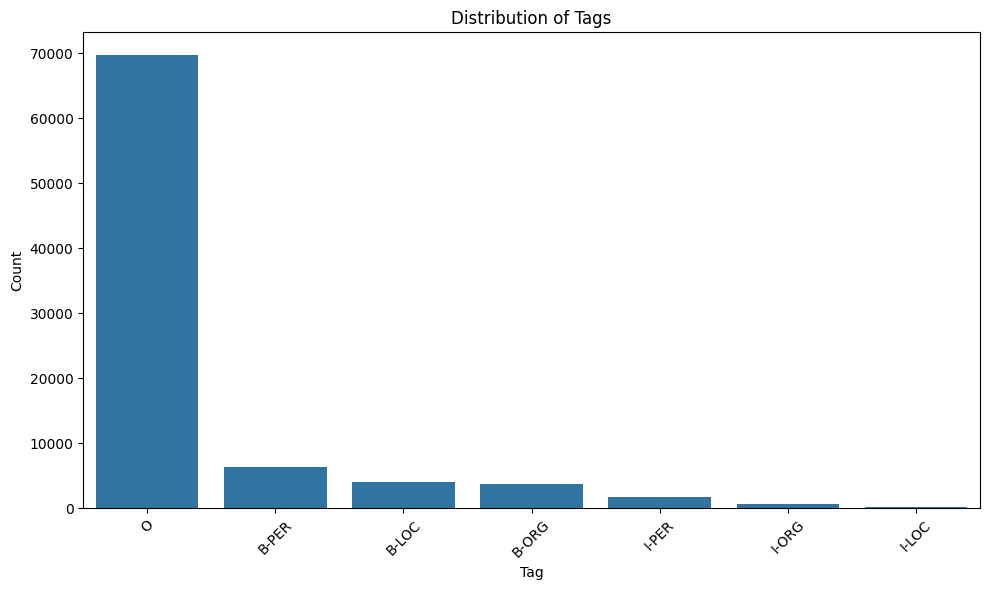

In [5]:
# Identify unique tags and their counts
tag_counts = df['tag'].value_counts()

# Display the unique tags and their counts
print("Unique tags and their counts:")
print(tag_counts)

# Create a bar chart to visualize the tag distribution
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.barplot(x=tag_counts.index, y=tag_counts.values)
plt.title('Distribution of Tags')
plt.xlabel('Tag')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [7]:
from transformers import AutoTokenizer
tokenizer_base = AutoTokenizer.from_pretrained("bert-base-cased")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/49.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/213k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/436k [00:00<?, ?B/s]

In [8]:
from tokenizers import BertWordPieceTokenizer
import os

# Initialize a tokenizer
tokenizer = BertWordPieceTokenizer(
    clean_text=True,
    handle_chinese_chars=False,  # Sinhala not Chinese
    strip_accents=False,         # keep Sinhala accents
    lowercase=False              # Sinhala is case-insensitive
)

# Train tokenizer on your corpus
# We need to create a text file from the dataset for tokenizer training
corpus_file = "sinhala_corpus.txt"
with open(corpus_file, "w", encoding="utf-8") as f:
    with open('/content/sinhala_ner_dataset_cleaned.conll', 'r', encoding="utf-8") as infile:
        for line in infile:
            line = line.strip()
            if line and len(line.split()) == 2:
                f.write(line.split()[0] + " ")
            elif not line:
                f.write("\n")


tokenizer.train(
    files=[corpus_file],
    vocab_size=30000,   # typical BERT vocab size
    min_frequency=2,    # ignore rare words
    special_tokens=["[PAD]", "[UNK]", "[CLS]", "[SEP]", "[MASK]"]
)

# Create the directory if it doesn't exist
save_directory = "kasun_sinhala_bert"
if not os.path.exists(save_directory):
    os.makedirs(save_directory)

# Save tokenizer files
tokenizer.save_model(save_directory)

['kasun_sinhala_bert/vocab.txt']

In [10]:
# Example sentence
example_sentence = "පාලමුන ඔබතමයි කාරයෝන්ට රාජපක්ෂලාටම් හර්ශ"

# Tokenize word by word using split
word_tokens = example_sentence.split()

# Print the word tokens
print("Original Sentence:", example_sentence)
print("Word Tokens:", word_tokens)

Original Sentence: පාලමුන ඔබතමයි කාරයෝන්ට රාජපක්ෂලාටම් හර්ශ
Word Tokens: ['පාලමුන', 'ඔබතමයි', 'කාරයෝන්ට', 'රාජපක්ෂලාටම්', 'හර්ශ']


# Task
Tokenize the entire dataset and align the tags to the tokens.

## Group data by sentence

### Subtask:
Group the words and tags in the DataFrame into individual sentences.


**Reasoning**:
Re-read the CoNLL file to group words and tags into sentences based on empty lines.



In [11]:
# Re-read the CoNLL file to group words and tags into sentences
sentences = []
current_sentence = []

with open('/content/sinhala_ner_dataset_cleaned.conll', 'r', encoding="utf-8") as f:
    for line in f:
        line = line.strip()
        if line:
            # Assuming each line is in the format "word tag"
            parts = line.split()
            if len(parts) == 2:
                word, tag = parts
                current_sentence.append({'word': word, 'tag': tag})
        else:
            # An empty line indicates the end of a sentence
            if current_sentence:
                sentences.append(current_sentence)
                current_sentence = []

# Append the last sentence if the file doesn't end with an empty line
if current_sentence:
    sentences.append(current_sentence)

# Display the first few sentences
print(f"Number of sentences: {len(sentences)}")
print("First sentence:", sentences[0])
print("Second sentence:", sentences[1])

Number of sentences: 9633
First sentence: [{'word': 'පාලමුන', 'tag': 'B-LOC'}]
Second sentence: [{'word': 'ඔබතමයි', 'tag': 'O'}, {'word': 'කාරයෝන්ට', 'tag': 'O'}, {'word': 'රාජපක්ෂලාටම්', 'tag': 'B-PER'}, {'word': 'හර්ශ', 'tag': 'B-PER'}, {'word': 'විපක්ශයට', 'tag': 'B-ORG'}, {'word': 'අවලද', 'tag': 'O'}, {'word': 'දැම්මාඇත්ත', 'tag': 'O'}, {'word': 'ඩොබිලාට', 'tag': 'O'}, {'word': 'පැන්චො', 'tag': 'O'}]


## Tokenize sentences and align tags

### Subtask:
Iterate through each sentence, apply the trained tokenizer to get the tokens, and align the original tags to these tokens.


**Reasoning**:
Load the trained tokenizer and iterate through the sentences to tokenize and align tags.



In [14]:
from transformers import AutoTokenizer
import logging

# Configure logging to suppress warnings from transformers if needed
# logging.basicConfig(level=logging.ERROR) # Uncomment to suppress warnings

# Load the trained tokenizer
tokenizer = AutoTokenizer.from_pretrained("kasun_sinhala_bert")

tokenized_aligned_data = []

# Iterate through each sentence
for sentence in sentences:
    words = [item['word'] for item in sentence]
    tags = [item['tag'] for item in sentence]

    # Tokenize the sentence, indicating that the input is already split into words
    # Request offset_mapping
    tokenized_input = tokenizer(words, is_split_into_words=True, return_offsets_mapping=True)

    # Access word_ids and offset_mapping from the Encoding object within BatchEncoding
    # Since we process one sentence at a time, tokenized_input contains a single Encoding object
    tokens = tokenizer.convert_ids_to_tokens(tokenized_input['input_ids'])
    word_ids = tokenized_input.word_ids() # Access word_ids using the method
    offset_mapping = tokenized_input['offset_mapping']


    aligned_tags = []
    previous_word_idx = None

    # Align tags to tokens
    for token_idx, word_idx in enumerate(word_ids):
        if word_idx is None:
            # Special tokens like [CLS], [SEP], [PAD]
            aligned_tags.append("O") # Or a special tag like "[IGN]"
        elif word_idx != previous_word_idx:
            # Start of a new word or a whole word token
            aligned_tags.append(tags[word_idx])
        else:
            # Continuation of a previous word (subword token)
            # Check if the current token is the start of the word (based on offset)
            # If the offset start is not 0, it's a subword
            if offset_mapping[token_idx][0] != 0:
                # For subwords, use the tag of the previous token from the same word
                # This is a common strategy, though others exist (e.g., I- tag for all subwords)
                 aligned_tags.append(tags[word_idx].replace('B-', 'I-')) # Change B- tags to I- for subwords
            else:
                 aligned_tags.append(tags[word_idx]) # For the first subword (which starts at offset 0)

        previous_word_idx = word_idx

    tokenized_aligned_data.append({'tokens': tokens, 'tags': aligned_tags})

# Display the first few tokenized and aligned sentences as an example
print("\nFirst tokenized and aligned sentence:")
print("Tokens:", tokenized_aligned_data[0]['tokens'])
print("Tags:", tokenized_aligned_data[0]['tags'])

print("\nSecond tokenized and aligned sentence:")
print("Tokens:", tokenized_aligned_data[1]['tokens'])
print("Tags:", tokenized_aligned_data[1]['tags'])


First tokenized and aligned sentence:
Tokens: ['[CLS]', 'පාලම', '##න', '[SEP]']
Tags: ['O', 'B-LOC', 'I-LOC', 'O']

Second tokenized and aligned sentence:
Tokens: ['[CLS]', 'ඔබ', '##තම', '##ය', 'කාරය', '##ො', '##නට', 'රාජපකෂ', '##ලාට', '##ම', 'හර', '##ශ', 'වප', '##ක', '##ශය', '##ට', 'අවලද', 'දැම', '##මා', '##ඇත', '##ත', 'ඩෙ', '##ා', '##බලා', '##ට', 'පැන', '##චෙ', '##ා', '[SEP]']
Tags: ['O', 'O', 'O', 'O', 'O', 'O', 'O', 'B-PER', 'I-PER', 'I-PER', 'B-PER', 'I-PER', 'B-ORG', 'I-ORG', 'I-ORG', 'I-ORG', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O']


## Format the data for model training

### Subtask:
Convert the tokenized sentences and aligned tags into a format suitable for training a Named Entity Recognition model, likely using a library like Hugging Face's `datasets`.


**Reasoning**:
Import the Dataset class, create a dictionary from the tokenized and aligned data, and then create a Dataset object from this dictionary. Finally, print the dataset structure.



In [15]:
from datasets import Dataset

# Create a dictionary from the tokenized and aligned data
dataset_dict = {
    'tokens': [item['tokens'] for item in tokenized_aligned_data],
    'tags': [item['tags'] for item in tokenized_aligned_data]
}

# Create a Dataset object
dataset = Dataset.from_dict(dataset_dict)

# Print the structure of the created dataset
print(dataset)

Dataset({
    features: ['tokens', 'tags'],
    num_rows: 9633
})


## Summary:

### Data Analysis Key Findings

*   The dataset contains 9633 sentences.
*   The tokenization process successfully aligned the original NER tags to the generated tokens, handling special tokens like `[CLS]`, `[SEP]`, and `[PAD]` by assigning them the "O" tag.
*   For subword tokens that are continuations of a word tagged with "B-", the aligned tag was changed to "I-", which is a standard practice in sequence tagging for subwords.
*   The final dataset, formatted for model training using the Hugging Face `datasets` library, contains 9633 entries, each with a list of tokens and their corresponding aligned tags.

### Insights or Next Steps

*   The formatted dataset is now ready for further processing, such as converting string tags into numerical IDs and splitting into training, validation, and test sets, before being used to train a Named Entity Recognition model.
*   Consider evaluating different subword tagging strategies (e.g., assigning "O" to all subwords, using the original tag for the first subword and "I-" for subsequent ones) during model training to see which yields the best performance.


In [16]:
# Display the first few tokenized and aligned sentences as an example
print("First tokenized and aligned sentence:")
print("Tokens:", tokenized_aligned_data[0]['tokens'])
print("Tags:", tokenized_aligned_data[0]['tags'])

print("\nSecond tokenized and aligned sentence:")
print("Tokens:", tokenized_aligned_data[1]['tokens'])
print("Tags:", tokenized_aligned_data[1]['tags'])

First tokenized and aligned sentence:
Tokens: ['[CLS]', 'පාලම', '##න', '[SEP]']
Tags: ['O', 'B-LOC', 'I-LOC', 'O']

Second tokenized and aligned sentence:
Tokens: ['[CLS]', 'ඔබ', '##තම', '##ය', 'කාරය', '##ො', '##නට', 'රාජපකෂ', '##ලාට', '##ම', 'හර', '##ශ', 'වප', '##ක', '##ශය', '##ට', 'අවලද', 'දැම', '##මා', '##ඇත', '##ත', 'ඩෙ', '##ා', '##බලා', '##ට', 'පැන', '##චෙ', '##ා', '[SEP]']
Tags: ['O', 'O', 'O', 'O', 'O', 'O', 'O', 'B-PER', 'I-PER', 'I-PER', 'B-PER', 'I-PER', 'B-ORG', 'I-ORG', 'I-ORG', 'I-ORG', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O']


In [17]:
# Calculate the total number of tokens
total_tokens = sum(len(item['tokens']) for item in tokenized_aligned_data)

# Print the total number of tokens
print(f"Total number of tokens in the dataset: {total_tokens}")

Total number of tokens in the dataset: 249706


In [20]:
from transformers import AutoTokenizer

# Load the trained tokenizer
tokenizer = AutoTokenizer.from_pretrained("./kasun_sinhala_bert")

# Decode tokens for the first few entries in tokenized_aligned_data
num_examples_to_show = 5
for i in range(min(num_examples_to_show, len(tokenized_aligned_data))):
    tokens = tokenized_aligned_data[i]['tokens']
    # Decode the tokens (excluding special tokens for a cleaner look)
    decoded_text = tokenizer.decode([tokenizer.convert_tokens_to_ids(token) for token in tokens if token not in tokenizer.all_special_tokens])

    print(f"Example {i+1}:")
    print("Original Tokens:", tokens)
    print("Decoded Text:", decoded_text)
    print("-" * 20)

Example 1:
Original Tokens: ['[CLS]', 'පාලම', '##න', '[SEP]']
Decoded Text: පාලමන
--------------------
Example 2:
Original Tokens: ['[CLS]', 'ඔබ', '##තම', '##ය', 'කාරය', '##ො', '##නට', 'රාජපකෂ', '##ලාට', '##ම', 'හර', '##ශ', 'වප', '##ක', '##ශය', '##ට', 'අවලද', 'දැම', '##මා', '##ඇත', '##ත', 'ඩෙ', '##ා', '##බලා', '##ට', 'පැන', '##චෙ', '##ා', '[SEP]']
Decoded Text: ඔබතමය කාරයොනට රාජපකෂලාටම හරශ වපකශයට අවලද දැමමාඇතත ඩොබලාට පැනචො
--------------------
Example 3:
Original Tokens: ['[CLS]', 'මක', '##ලෑව', '[SEP]']
Decoded Text: මකලෑව
--------------------
Example 4:
Original Tokens: ['[CLS]', 'නොද', '##නන', '##ා', 'තන', '##ම', 'හෙන', '##යක', '##පෙ', '##ාලෙ', '##ාන', '##න', '##රව', '##ෙ', 'දෙය', '##යන', '##ගෙම', 'පහට', '##ය', 'ආයෙම', '##ත', 'පාර', '##ලම', '##ෙන', '##තව', '##ට', 'ගෙනාවෙ', '##ා', '##ත', 'මද', '##වෙ', '##ය', 'වැ', '##ස', '##ස', 'ම', '##ණ', '##මර', 'අපාගත', 'ම', '##සලය', '##ො', 'බෙර', '##නෙ', 'ශ', '##රල', '##න', '##පය', 'අධ', '##කරණයට', '##ම', 'භාර', 'ඉවර', '##යනෙ', 'ඉත', '##හා'

# Task
Train a Named Entity Recognition (NER) model using the provided dataset, splitting it into training, validation, and test sets, and using a custom tokenizer.

## Define tag mappings

### Subtask:
Create dictionaries to map tag strings to numerical IDs and vice versa.


**Reasoning**:
Create dictionaries to map tag strings to numerical IDs and vice versa using the unique tags from the dataset.



In [22]:
# Get all unique tags from the dataset
unique_tags = sorted(list(set(tag for sentence_tags in dataset['tags'] for tag in sentence_tags)))

# Create tag_to_id and id_to_tag dictionaries
tag_to_id = {tag: i for i, tag in enumerate(unique_tags)}
id_to_tag = {i: tag for tag, i in tag_to_id.items()}

# Print the dictionaries
print("Tag to ID mapping:", tag_to_id)
print("ID to Tag mapping:", id_to_tag)

Tag to ID mapping: {'B-LOC': 0, 'B-ORG': 1, 'B-PER': 2, 'I-LOC': 3, 'I-ORG': 4, 'I-PER': 5, 'O': 6}
ID to Tag mapping: {0: 'B-LOC', 1: 'B-ORG', 2: 'B-PER', 3: 'I-LOC', 4: 'I-ORG', 5: 'I-PER', 6: 'O'}


## Load a pre-trained model

### Subtask:
Choose and load a suitable pre-trained model for token classification (NER is a token classification task).


**Reasoning**:
Import the necessary class and load a pre-trained model for token classification, providing the number of labels and the tag mappings.



In [23]:
from transformers import AutoModelForTokenClassification

# Define the number of unique tags
num_labels = len(unique_tags)

# Load a pre-trained model suitable for token classification
# Using a multilingual model as a starting point
model = AutoModelForTokenClassification.from_pretrained(
    "bert-base-multilingual-cased",  # A common multilingual BERT model
    num_labels=num_labels,
    id2label=id_to_tag,
    label2id=tag_to_id
)

print("Pre-trained model loaded successfully.")

config.json:   0%|          | 0.00/625 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/714M [00:00<?, ?B/s]

Some weights of BertForTokenClassification were not initialized from the model checkpoint at bert-base-multilingual-cased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Pre-trained model loaded successfully.


## Prepare data for training

### Subtask:
Tokenize the input data and align the tags to the tokens, converting string tags to numerical IDs.


**Reasoning**:
Map the string tags to numerical IDs and then split the dataset into training, validation, and test sets.



In [24]:
# Map string tags to numerical IDs
def align_tags_to_ids(example):
    example['tags'] = [tag_to_id[tag] for tag in example['tags']]
    return example

dataset = dataset.map(align_tags_to_ids)

# Print the structure and an example of the modified dataset
print(dataset)
print("\nFirst example with numerical tags:")
print("Tokens:", dataset[0]['tokens'])
print("Tags (IDs):", dataset[0]['tags'])

# Split the dataset
train_test_split = dataset.train_test_split(test_size=0.2, seed=42)
train_dataset = train_test_split['train']
test_valid_split = train_test_split['test'].train_test_split(test_size=0.5, seed=42)
validation_dataset = test_valid_split['train']
test_dataset = test_valid_split['test']


# Print the sizes of the splits
print("\nDataset sizes:")
print(f"Training set size: {len(train_dataset)}")
print(f"Validation set size: {len(validation_dataset)}")
print(f"Test set size: {len(test_dataset)}")

Map:   0%|          | 0/9633 [00:00<?, ? examples/s]

Dataset({
    features: ['tokens', 'tags'],
    num_rows: 9633
})

First example with numerical tags:
Tokens: ['[CLS]', 'පාලම', '##න', '[SEP]']
Tags (IDs): [6, 0, 3, 6]

Dataset sizes:
Training set size: 7706
Validation set size: 963
Test set size: 964


## Define training arguments

### Subtask:
Set up the training parameters such as learning rate, number of epochs, batch size, etc.


**Reasoning**:
Import TrainingArguments and instantiate it with the specified parameters.



In [26]:
from transformers import TrainingArguments

# Set up training arguments
training_args = TrainingArguments(
    output_dir="./ner_model_output",  # Directory for saving model checkpoints and outputs
    num_train_epochs=3,               # Number of training epochs
    per_device_train_batch_size=16,   # Batch size for training
    per_device_eval_batch_size=16,    # Batch size for evaluation
    warmup_steps=500,                 # Number of warmup steps for learning rate scheduler
    weight_decay=0.01,                # Strength of weight decay
    eval_strategy="epoch",            # Evaluate at the end of each epoch
    logging_dir="./ner_logs",         # Directory for storing logs
    logging_steps=10,                 # Log training progress every 10 steps
    save_strategy="epoch",            # Save model checkpoint at the end of each epoch
    learning_rate=2e-5,               # Learning rate
    seed=42,                          # Random seed for reproducibility
    # Add more arguments as needed, e.g., report_to="tensorboard"
)

# Print the training arguments
print(training_args)

TrainingArguments(
_n_gpu=0,
accelerator_config={'split_batches': False, 'dispatch_batches': None, 'even_batches': True, 'use_seedable_sampler': True, 'non_blocking': False, 'gradient_accumulation_kwargs': None, 'use_configured_state': False},
adafactor=False,
adam_beta1=0.9,
adam_beta2=0.999,
adam_epsilon=1e-08,
auto_find_batch_size=False,
average_tokens_across_devices=False,
batch_eval_metrics=False,
bf16=False,
bf16_full_eval=False,
data_seed=None,
dataloader_drop_last=False,
dataloader_num_workers=0,
dataloader_persistent_workers=False,
dataloader_pin_memory=True,
dataloader_prefetch_factor=None,
ddp_backend=None,
ddp_broadcast_buffers=None,
ddp_bucket_cap_mb=None,
ddp_find_unused_parameters=None,
ddp_timeout=1800,
debug=[],
deepspeed=None,
disable_tqdm=False,
do_eval=True,
do_predict=False,
do_train=False,
eval_accumulation_steps=None,
eval_delay=0,
eval_do_concat_batches=True,
eval_on_start=False,
eval_steps=None,
eval_strategy=IntervalStrategy.EPOCH,
eval_use_gather_object=False

## Create a trainer

### Subtask:
Initialize a `Trainer` object from the Hugging Face `transformers` library with the model, training arguments, and datasets.


**Reasoning**:
Import the Trainer class and initialize it with the model, training arguments, and datasets.



In [27]:
from transformers import Trainer

# Initialize the Trainer
trainer = Trainer(
    model=model,                         # the instantiated 🤗 Transformers model to be trained
    args=training_args,                  # training arguments, defined above
    train_dataset=train_dataset,         # training dataset
    eval_dataset=validation_dataset      # evaluation dataset
)

print("Trainer initialized successfully.")

Trainer initialized successfully.


## Train the model

### Subtask:
Train the Named Entity Recognition model using the initialized `Trainer`.


In [ ]:
from transformers import Trainer, TrainingArguments, DataCollatorForTokenClassification

# Update training arguments (keeping remove_unused_columns=False)
training_args = TrainingArguments(
    output_dir="./ner_model_output",
    num_train_epochs=3,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    warmup_steps=500,
    weight_decay=0.01,
    eval_strategy="epoch",
    logging_dir="./ner_logs",
    logging_steps=10,
    save_strategy="epoch",
    learning_rate=2e-5,
    seed=42,
    remove_unused_columns=False # Keep columns not used by the model
)

# Initialize a data collator for token classification
data_collator = DataCollatorForTokenClassification(tokenizer=tokenizer)

# Re-initialize the Trainer with the data collator
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=validation_dataset,
    data_collator=data_collator # Add the data collator
)

# Train the model
trainer.train()

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:666: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


Epoch,Training Loss,Validation Loss


## Evaluate the model

### Subtask:
Evaluate the trained model on the validation and test sets to assess its performance.


In [7]:
from transformers import Trainer, TrainingArguments, DataCollatorForTokenClassification, AutoTokenizer, AutoModelForTokenClassification
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import numpy as np
from datasets import Dataset

# Re-read the CoNLL file to group words and tags into sentences
sentences = []
current_sentence = []

with open('/content/sinhala_ner_dataset_cleaned.conll', 'r', encoding="utf-8") as f:
    for line in f:
        line = line.strip()
        if line:
            parts = line.split()
            if len(parts) == 2:
                word, tag = parts
                current_sentence.append({'word': word, 'tag': tag})
        else:
            if current_sentence:
                sentences.append(current_sentence)
                current_sentence = []

if current_sentence:
    sentences.append(current_sentence)

# Load the trained tokenizer
tokenizer = AutoTokenizer.from_pretrained("./kasun_sinhala_bert")

# Re-create tokenized_aligned_data
tokenized_aligned_data = []

for sentence in sentences:
    words = [item['word'] for item in sentence]
    tags = [item['tag'] for item in sentence]

    tokenized_input = tokenizer(words, is_split_into_words=True, return_offsets_mapping=True)

    tokens = tokenizer.convert_ids_to_tokens(tokenized_input['input_ids'])
    word_ids = tokenized_input.word_ids()
    offset_mapping = tokenized_input['offset_mapping']

    aligned_tags = []
    previous_word_idx = None

    for token_idx, word_idx in enumerate(word_ids):
        if word_idx is None:
            aligned_tags.append("O")
        elif word_idx != previous_word_idx:
            aligned_tags.append(tags[word_idx])
        else:
            if offset_mapping[token_idx][0] != 0:
                aligned_tags.append(tags[word_idx].replace('B-', 'I-'))
            else:
                 aligned_tags.append(tags[word_idx])

        previous_word_idx = word_idx

    tokenized_aligned_data.append({'tokens': tokens, 'tags': aligned_tags})


# Re-create the Dataset from tokenized_aligned_data
dataset_dict = {
    'tokens': [item['tokens'] for item in tokenized_aligned_data],
    'tags': [item['tags'] for item in tokenized_aligned_data]
}
dataset = Dataset.from_dict(dataset_dict)

# Re-create unique_tags, tag_to_id, and id_to_tag
unique_tags = sorted(list(set(tag for sentence_tags in dataset['tags'] for tag in sentence_tags)))
tag_to_id = {tag: i for i, tag in enumerate(unique_tags)}
id_to_tag = {i: tag for tag, i in tag_to_id.items()}

# Define function to tokenize and align tags for model input
def tokenize_and_align_labels(examples):
    tokenized_inputs = tokenizer(
        examples["tokens"], truncation=True, is_split_into_words=True, padding="max_length"
    )
    labels = []
    for i, label in enumerate(examples[f"tags"]):
        word_ids = tokenized_inputs.word_ids(batch_index=i)
        previous_word_idx = None
        label_ids = []
        for word_idx in word_ids:
            if word_idx is None:
                label_ids.append(-100)
            elif word_idx != previous_word_idx:
                label_ids.append(tag_to_id[label[word_idx]])
            else:
                label_ids.append(tag_to_id[label[word_idx]])
            previous_word_idx = word_idx
        labels.append(label_ids)

    tokenized_inputs["labels"] = labels
    return tokenized_inputs


# Apply the tokenization and alignment function to the dataset
processed_dataset = dataset.map(tokenize_and_align_labels, batched=True)

# Remove the original 'tokens' and 'tags' columns as they are no longer needed by the model
processed_dataset = processed_dataset.remove_columns(['tokens', 'tags'])

# Split the processed dataset
train_test_split = processed_dataset.train_test_split(test_size=0.2, seed=42)
train_dataset = train_test_split['train']
test_valid_split = train_test_split['test'].train_test_split(test_size=0.5, seed=42)
validation_dataset = test_valid_split['train']
test_dataset = test_valid_split['test']


# Re-define training arguments (keeping remove_unused_columns=False)
training_args = TrainingArguments(
    output_dir="./ner_model_output",
    num_train_epochs=3,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    warmup_steps=500,
    weight_decay=0.01,
    eval_strategy="epoch",
    logging_dir="./ner_logs",
    logging_steps=10,
    save_strategy="epoch",
    learning_rate=2e-5,
    seed=42,
    remove_unused_columns=False # Keep columns not used by the model
)

# Define the number of unique tags
num_labels = len(unique_tags)

# Load the model (assuming 'model' variable is not available, load from the output directory if saved)
try:
    model = AutoModelForTokenClassification.from_pretrained("./ner_model_output")
except:
    # If model was not saved or loading fails, re-initialize the base model
    print("Could not load trained model from output directory. Re-initializing base model.")
    model = AutoModelForTokenClassification.from_pretrained(
        "bert-base-multilingual-cased",
        num_labels=num_labels,
        id2label=id_to_tag,
        label2id=tag_to_id
    )

# Initialize a data collator for token classification
data_collator = DataCollatorForTokenClassification(tokenizer=tokenizer)

# Re-initialize the Trainer with the data collator
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=validation_dataset,
    data_collator=data_collator
)

print("Trainer re-initialized successfully. Proceeding with evaluation and prediction.")

# Evaluate on the validation set
print("Evaluating on the validation set...")
validation_results = trainer.evaluate(eval_dataset=validation_dataset)
print("Validation Results:", validation_results)

# Get predictions for the test set
print("\nGetting predictions for the test set...")
predictions = trainer.predict(test_dataset)
predicted_ids = predictions.predictions.argmax(axis=-1)
true_ids = predictions.label_ids

# Function to flatten lists and remove ignored indices
def flatten_and_filter(list_of_lists, ignore_index=-100):
    flat_list = []
    for sublist in list_of_lists:
        for item in sublist:
            if item != ignore_index:
                flat_list.append(item)
    return flat_list

# Flatten and filter out ignored indices from true_ids
# Assuming -100 was used as the ignore index during training
true_ids_flat = flatten_and_filter(true_ids)

# Flatten and filter predicted_ids to match the filtered true_ids
# We need to filter predicted_ids based on the original structure of true_ids
predicted_ids_flat = []
for i in range(len(true_ids)):
    for j in range(len(true_ids[i])):
        if true_ids[i][j] != -100:
            predicted_ids_flat.append(predicted_ids[i][j])

# Decode predicted and true IDs to tags
predicted_tags = [id_to_tag[id] for id in predicted_ids_flat]
true_tags = [id_to_tag[id] for id in true_ids_flat]

# Calculate metrics
print("\nCalculating evaluation metrics on the test set...")
accuracy = accuracy_score(true_tags, predicted_tags)
precision = precision_score(true_tags, predicted_tags, average='weighted', zero_division=0)
recall = recall_score(true_tags, predicted_tags, average='weighted', zero_division=0)
f1 = f1_score(true_tags, predicted_tags, average='weighted', zero_division=0)

print(f"Test Accuracy: {accuracy:.4f}")
print(f"Test Precision (weighted): {precision:.4f}")
print(f"Test Recall (weighted): {recall:.4f}")
print(f"Test F1-Score (weighted): {f1:.4f}")

Map:   0%|          | 0/9633 [00:00<?, ? examples/s]

Asking to pad to max_length but no maximum length is provided and the model has no predefined maximum length. Default to no padding.
Asking to truncate to max_length but no maximum length is provided and the model has no predefined maximum length. Default to no truncation.


Could not load trained model from output directory. Re-initializing base model.


Some weights of BertForTokenClassification were not initialized from the model checkpoint at bert-base-multilingual-cased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:666: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


Trainer re-initialized successfully. Proceeding with evaluation and prediction.
Evaluating on the validation set...


wandb: Currently logged in as: udayangakasun696 (udayangakasun696-university-of-jaffna) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


Validation Results: {'eval_loss': 1.878785490989685, 'eval_model_preparation_time': 0.0035, 'eval_runtime': 469.4328, 'eval_samples_per_second': 2.051, 'eval_steps_per_second': 0.13}

Getting predictions for the test set...


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:666: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)



Calculating evaluation metrics on the test set...
Test Accuracy: 0.1163
Test Precision (weighted): 0.5718
Test Recall (weighted): 0.1163
Test F1-Score (weighted): 0.1102
